In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import pylab as plt
import networkx as nx
from sklearn.metrics import pairwise_distances
from sklearn.decomposition import PCA

In [2]:
from modules import geometry
from modules import graphio
from modules import metrics
from modules import visualization as vis
from modules import stress_experiments
from modules.projector import MDSTorusProjector

def torus_stress(X, D, proj):
    geod = geometry.make_torus_geod(proj.alpha_, proj.r0_, proj.r1_, proj.theta_)
    return metrics.geodesic_stress(X, D, geod)

## Lattice graph

stress=0.09495


<Axes: >

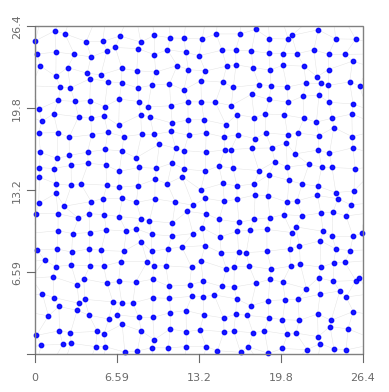

In [3]:
G, D = graphio.get_periodic_lattice(20, 20)

# D /= np.max(D)

proj = MDSTorusProjector()
X = proj.fit_transform(D)
print(f"stress={torus_stress(X, D, proj):.4g}")

fig, ax = plt.subplots()
vis.plot_embedding_with_torus_edges(G=G, torus=proj, ax=ax)

### 20×20 grid: comparing learn modes

[alpha]  alpha=26.36  stress=0.09495
[square]  r=26.37  stress=0.09493
[rectangular]  r0=26.37  r1=26.36  ratio=1.000  stress=0.09493


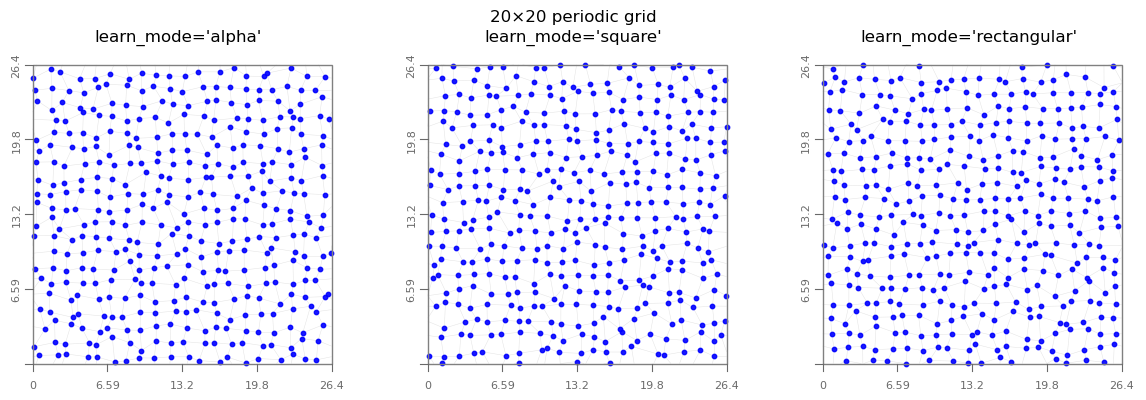

In [4]:
G20, D20 = graphio.get_periodic_lattice(20, 20)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, mode in zip(axes, ['alpha', 'square', 'rectangular']):
    proj = MDSTorusProjector()
    X = proj.fit_transform(D20, learn_mode=mode)
    stress = torus_stress(X, D20, proj)
    if mode == 'alpha':
        print(f"[{mode}]  alpha={proj.alpha_:.4g}  stress={stress:.4g}")
    elif mode == 'square':
        print(f"[{mode}]  r={proj.r0_:.4g}  stress={stress:.4g}")
    else:
        print(f"[{mode}]  r0={proj.r0_:.4g}  r1={proj.r1_:.4g}  ratio={proj.r1_/proj.r0_:.3f}  stress={stress:.4g}")
    vis.plot_embedding_with_torus_edges(G=G20, torus=proj, ax=ax)
    ax.set_title(f"learn_mode='{mode}'")
plt.suptitle("20×20 periodic grid")
plt.tight_layout()

## 20×40 periodic grid

In [5]:
G40, D40 = graphio.get_periodic_lattice(20, 40)
colors = [j for (i, j) in G40.nodes()]
colors_short = [i for (i, j) in G40.nodes()]

[alpha]  alpha=39.09  stress=0.2156
[square]  r=39.07  stress=0.2146
[rectangular]  r0=32.31  r1=45.95  ratio=1.422  stress=0.1035


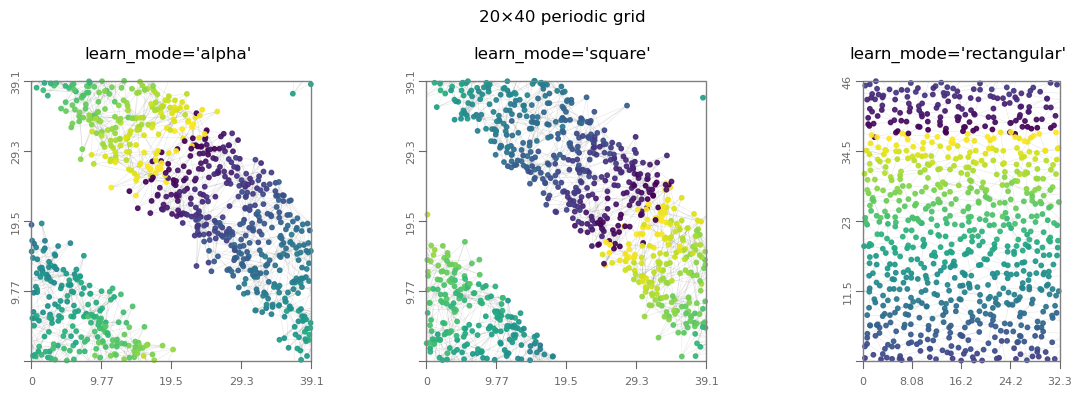

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, mode in zip(axes, ['alpha', 'square', 'rectangular']):
    proj = MDSTorusProjector()
    X = proj.fit_transform(D40, learn_mode=mode)
    stress = torus_stress(X, D40, proj)
    if mode == 'alpha':
        print(f"[{mode}]  alpha={proj.alpha_:.4g}  stress={stress:.4g}")
    elif mode == 'square':
        print(f"[{mode}]  r={proj.r0_:.4g}  stress={stress:.4g}")
    else:
        print(f"[{mode}]  r0={proj.r0_:.4g}  r1={proj.r1_:.4g}  ratio={proj.r1_/proj.r0_:.3f}  stress={stress:.4g}")
    vis.plot_embedding_with_torus_edges(G=G40, torus=proj, ax=ax, colors=colors)
    ax.set_title(f"learn_mode='{mode}'")
plt.suptitle("20×40 periodic grid")
plt.tight_layout()

### 20×40 grid: fixed 1:2 ratio, learn scale only (sanity check)

In [47]:
from modules.geometry import rect_distance

[fixed ratio]    alpha=25.11  r0=1  r1=2  stress=0.1257
[learned ratio]  alpha=1  r0=45.98  r1=32.29  ratio=0.702  stress=0.1032


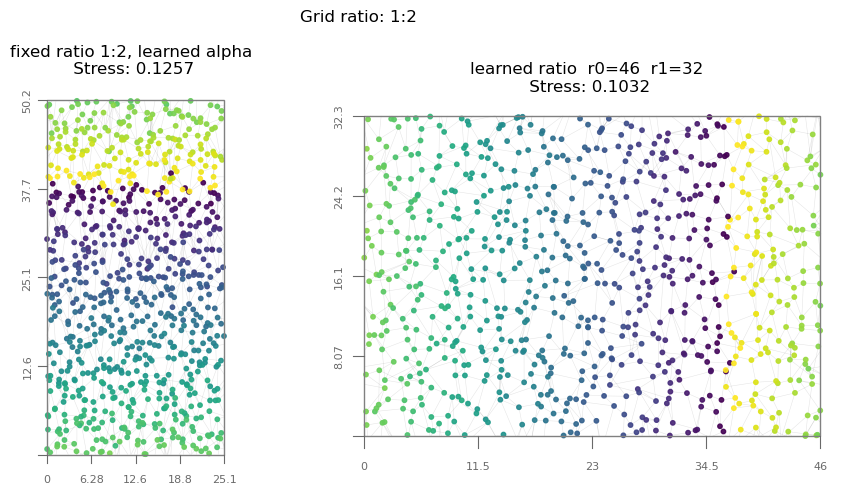

In [53]:
colors = [j for (i, j) in G40.nodes()]

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

proj = MDSTorusProjector()
X = proj.fit_transform(D40, learn_mode='alpha', r0_init=1.0, r1_init=2.0)
stress = torus_stress(X, D40, proj)
print(f"[fixed ratio]    alpha={proj.alpha_:.4g}  r0={proj.r0_:.4g}  r1={proj.r1_:.4g}  stress={stress:.4g}")
vis.plot_embedding_with_torus_edges(G=G40, torus=proj, ax=axes[0], colors=colors)


axes[0].set_title(f"fixed ratio 1:2, learned alpha\n Stress: {stress:.4g}")


proj = MDSTorusProjector()
X = proj.fit_transform(D40, learn_mode='rectangular', r0_init=25.0, r1_init=50.0)
stress = torus_stress(X, D40, proj)
print(f"[learned ratio]  alpha={proj.alpha_:.4g}  r0={proj.r0_:.4g}  r1={proj.r1_:.4g}  ratio={proj.r1_/proj.r0_:.3f}  stress={stress:.4g}")
vis.plot_embedding_with_torus_edges(G=G40, torus=proj, ax=axes[1], colors=colors)


axes[1].set_title(f"learned ratio  r0={proj.r0_:.2g}  r1={proj.r1_:.2g}\n Stress: {stress:.4g}")

fig.suptitle("Grid ratio: 1:2")

plt.tight_layout()

fig.savefig('poster/rectangle.pdf', dpi=200)

In [ ]:
colors = [j for (i, j) in G40.nodes()]

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

proj = MDSTorusProjector()
X = proj.fit_transform(D40, learn_mode='alpha', r0_init=1.0, r1_init=2.0)
print(f"[fixed ratio]    alpha={proj.alpha_:.4g}  r0={proj.r0_:.4g}  r1={proj.r1_:.4g}  stress={torus_stress(X, D40, proj):.4g}")
vis.plot_embedding_with_torus_edges(G=G40, torus=proj, ax=axes[0], colors=colors)
axes[0].set_title("fixed ratio 1:2, learned alpha")

proj = MDSTorusProjector()
X = proj.fit_transform(D40, learn_mode='rectangular', r0_init=25.0, r1_init=50.0)
print(f"[learned ratio]  alpha={proj.alpha_:.4g}  r0={proj.r0_:.4g}  r1={proj.r1_:.4g}  ratio={proj.r1_/proj.r0_:.3f}  stress={torus_stress(X, D40, proj):.4g}")
vis.plot_embedding_with_torus_edges(G=G40, torus=proj, ax=axes[1], colors=colors)
axes[1].set_title(f"learned ratio (init 1:3)  r0={proj.r0_:.2g}  r1={proj.r1_:.2g}")

plt.tight_layout()

In [8]:
RUN_EXPENSIVE = True

## Grid cells

In [9]:
if RUN_EXPENSIVE:
    a = np.load("grid_cells_4800.npz")
    data = a['data']
    spikes = a['spikes']

    D = pairwise_distances(data)
    proj = MDSTorusProjector()
    X = proj.fit_transform(D)
    print(f"stress={torus_stress(X, D, proj):.4g}")

stress=0.2498


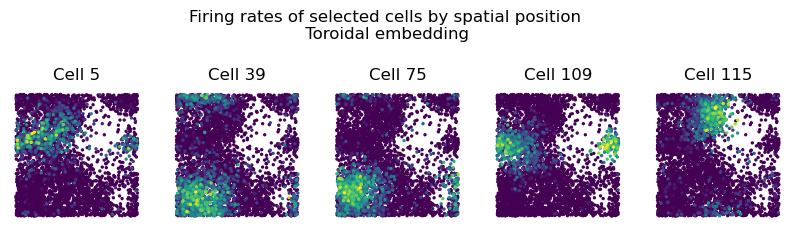

In [10]:
if RUN_EXPENSIVE:
    # spatial location of firing rates
    fig, ax = plt.subplots(1, 5, figsize=(10, 3))

    cell_ids = [5, 39, 75, 109, 115] # cells with clearly structured firing pattern

    xx = X[:,0]
    yy = X[:,1]
    for i, idx in enumerate(cell_ids):
        order  = np.argsort(spikes[:, idx])  # to plot interesting time points on top
        ax[i].scatter(xx[order], yy[order], c=spikes[order, idx], s=2)
        ax[i].set_title(f"Cell {idx}")
        ax[i].axis("off")
        ax[i].set_aspect("equal")
    fig.suptitle("Firing rates of selected cells by spatial position\n Toroidal embedding")

## Yoda and Bulldog

In [11]:
if RUN_EXPENSIVE:
    pca = np.load("yoda_bulldog_pca50.npy")

    D = pairwise_distances(pca[:,:10])
    proj = MDSTorusProjector()
    X = proj.fit_transform(D)
    print(f"stress={torus_stress(X, D, proj):.4g}")

stress=0.4344


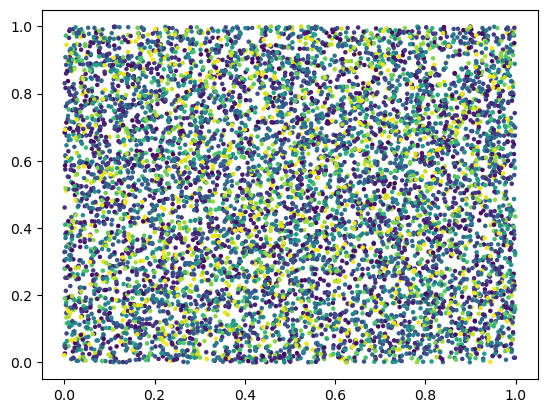

In [12]:
if RUN_EXPENSIVE:
    fig, ax = plt.subplots()
    plt.scatter(X[:,0], X[:,1],c=pca[:,1],s=5)

## Block models

In [13]:
G = nx.planted_partition_graph(5, 100, 0.2, 0.01)
d, nodes = graphio.apsp_distance_matrix(G)

proj = MDSTorusProjector()
X_torus = proj.fit_transform(d)
print(f"stress={torus_stress(X_torus, d, proj):.4g}")

stress=0.2943


<Axes: >

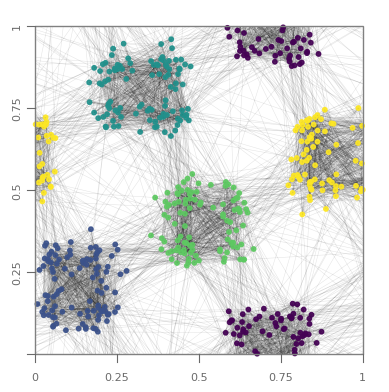

In [14]:
colors = [0] * 100 + [1] * 100 + [2] * 100 + [3] * 100 + [4] * 100
vis.plot_embedding_with_torus_edges(X_torus, G, colors=colors)

## Rhombic torus (theta = 60°)

alpha=28.09  r0=1  r1=1  stress=0.2475


Text(0.5, 1.0, '20×20 grid, rhombic torus θ=60°')

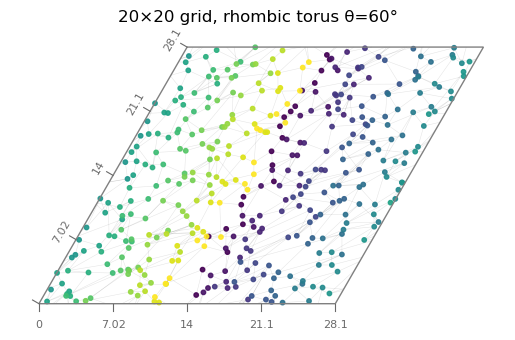

In [15]:
G20, D20 = graphio.get_periodic_lattice(20, 20)
colors20 = [i for (i, j) in G20.nodes()]

proj = MDSTorusProjector()
X = proj.fit_transform(D20, learn_mode='alpha', theta=60.0)
print(f"alpha={proj.alpha_:.4g}  r0={proj.r0_:.4g}  r1={proj.r1_:.4g}  stress={torus_stress(X, D20, proj):.4g}")

fig, ax = plt.subplots()
vis.plot_embedding_with_torus_edges(G=G20, torus=proj, ax=ax, colors=colors20)
ax.set_title("20×20 grid, rhombic torus θ=60°")

alpha=2.646  r0=1  r1=1  stress=2.978e-12


Text(0.5, 1.0, 'K7, rhombic torus θ=60°')

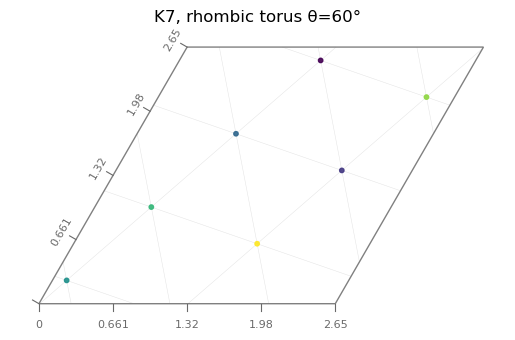

In [16]:
K7 = nx.complete_graph(7)
D_K7, _ = graphio.apsp_distance_matrix(K7)

proj_k7 = MDSTorusProjector()
X_k7 = proj_k7.fit_transform(D_K7, learn_mode='alpha', theta=60.0)
print(f"alpha={proj_k7.alpha_:.4g}  r0={proj_k7.r0_:.4g}  r1={proj_k7.r1_:.4g}  stress={torus_stress(X_k7, D_K7, proj_k7):.4g}")

fig, ax = plt.subplots()
vis.plot_embedding_with_torus_edges(G=K7, torus=proj_k7, ax=ax, colors=list(range(7)))
ax.set_title("K7, rhombic torus θ=60°")

alpha=6.711  r0=1  r1=1  stress=0.2579


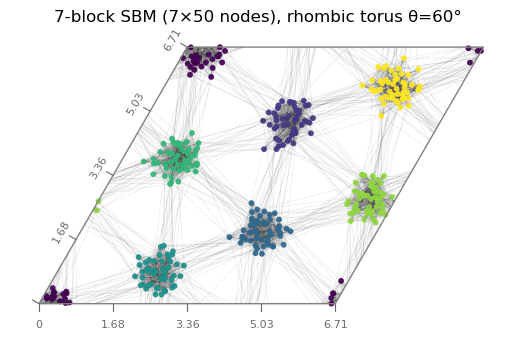

In [54]:
k = 50
G_sbm = nx.planted_partition_graph(7, k, 0.5, 0.01, seed=0)
D_sbm, _ = graphio.apsp_distance_matrix(G_sbm)

proj_sbm = MDSTorusProjector()
X_sbm = proj_sbm.fit_transform(D_sbm, learn_mode='alpha', theta=60.0)
print(f"alpha={proj_sbm.alpha_:.4g}  r0={proj_sbm.r0_:.4g}  r1={proj_sbm.r1_:.4g}  stress={torus_stress(X_sbm, D_sbm, proj_sbm):.4g}")

colors_sbm = [b for b in range(7) for _ in range(k)]
fig, ax = plt.subplots()
vis.plot_embedding_with_torus_edges(G=G_sbm, torus=proj_sbm, ax=ax, colors=colors_sbm)
ax.set_title("7-block SBM (7×50 nodes), rhombic torus θ=60°")

fig.savefig("poster/rhombic_sbm.pdf",dpi=200)

In [55]:
# Periodic triangular/hexagonal lattice on the torus.
# Each node has 6 neighbors: ±e0, ±e1, ±(e0 - e1).
# This graph is naturally compatible with a 60° rhombic torus. Here the geometry is fixed, not learned
def periodic_hex_lattice(n, m=None):
    if m is None:
        m = n
    G = nx.Graph()
    for i in range(n):
        for j in range(m):
            G.add_node((i, j))
    directions = [
        (1, 0),
        (0, 1),
        (1, -1),
    ]
    for i in range(n):
        for j in range(m):
            for di, dj in directions:
                u = (i, j)
                v = ((i + di) % n, (j + dj) % m)
                G.add_edge(u, v)
    return G

alpha=22.18  r0=1  r1=1  stress=0.04505


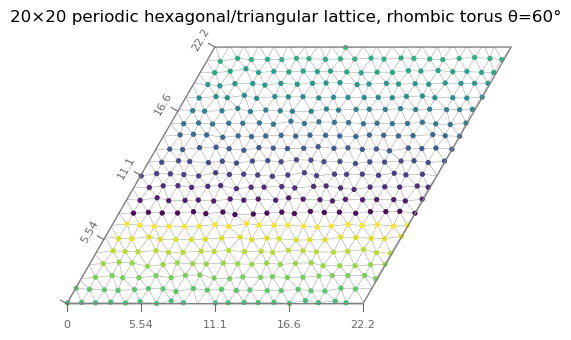

In [56]:
n = 20
G_hex = periodic_hex_lattice(n)
D_hex, _ = graphio.apsp_distance_matrix(G_hex)

proj_hex = MDSTorusProjector()
X_hex = proj_hex.fit_transform(D_hex, learn_mode="alpha", theta=60.0)
# X_hex = proj_hex.fit_transform(D_hex, learn_mode="alpha", theta=90.0)

print(f"alpha={proj_hex.alpha_:.4g}  r0={proj_hex.r0_:.4g}  r1={proj_hex.r1_:.4g}  stress={torus_stress(X_hex, D_hex, proj_hex):.4g}")

colors_hex = [i for (i, j) in G_hex.nodes()]
fig, ax = plt.subplots()
vis.plot_embedding_with_torus_edges(
    G=G_hex,
    torus=proj_hex,
    ax=ax,
    colors=colors_hex,
    edge_alpha=0.35,
    s=8,
)
ax.set_title("20×20 periodic hexagonal/triangular lattice, rhombic torus θ=60°")

fig.savefig("poster/rhombic-lattic.pdf",dpi=200)

alpha=19.83  r0=1  r1=1  stress=0.2058


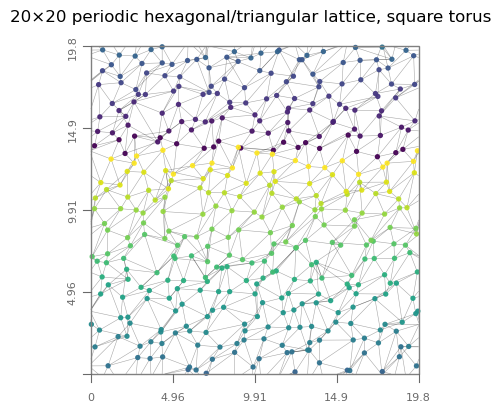

In [60]:
n = 20
G_hex = periodic_hex_lattice(n)
D_hex, _ = graphio.apsp_distance_matrix(G_hex)

proj_square = MDSTorusProjector()
X_hex = proj_square.fit_transform(D_hex, learn_mode="alpha")
# X_hex = proj_hex.fit_transform(D_hex, learn_mode="alpha", theta=90.0)

print(f"alpha={proj_square.alpha_:.4g}  r0={proj_square.r0_:.4g}  r1={proj_square.r1_:.4g}  stress={torus_stress(X_hex, D_hex, proj_square):.4g}")

colors_hex = [i for (i, j) in G_hex.nodes()]
fig, ax = plt.subplots()
vis.plot_embedding_with_torus_edges(
    G=G_hex,
    torus=proj_square,
    ax=ax,
    colors=colors_hex,
    edge_alpha=0.35,
    s=8,
)
ax.set_title("20×20 periodic hexagonal/triangular lattice, square torus")

fig.savefig("poster/rhombic-lattic-square.pdf",dpi=200)

In [20]:
# Learnable angle in rhombus / full parallelogram

In [21]:
# hex grid --> does correct torus geometry get learned?

In [22]:
G_hex = periodic_hex_lattice(20)
D_hex, _ = graphio.apsp_distance_matrix(G_hex)
colors_hex = [i for (i, j) in G_hex.nodes()]


In [23]:
# rhombic: learn the angle (start off the square saddle at theta=90)
proj_r = MDSTorusProjector()
Xr = proj_r.fit_transform(D_hex, learn_mode='rhombic', theta=100.0)
print('rhombic on hex:', 'alpha=%.4g' % proj_r.alpha_,
      'theta=%.1f' % np.degrees(proj_r.theta_),
      'r1/r0=%.3f' % (proj_r.r1_ / proj_r.r0_),
      'stress=%.4g' % torus_stress(Xr, D_hex, proj_r))


rhombic on hex: alpha=22.17 theta=60.0 r1/r0=1.000 stress=0.04536


In [24]:
# parallelogram: free shape
proj_p = MDSTorusProjector()
Xp = proj_p.fit_transform(D_hex, learn_mode='parallelogram')
print('parallelogram on hex:', 'alpha=%.4g' % proj_p.alpha_,
      'x=%.4g' % proj_p.x_, 'y=%.4g' % proj_p.y_,
      'theta=%.1f' % np.degrees(proj_p.theta_),
      'stress=%.4g' % torus_stress(Xp, D_hex, proj_p))


parallelogram on hex: alpha=22.15 x=-0.4991 y=0.8676 theta=119.9 stress=0.04543


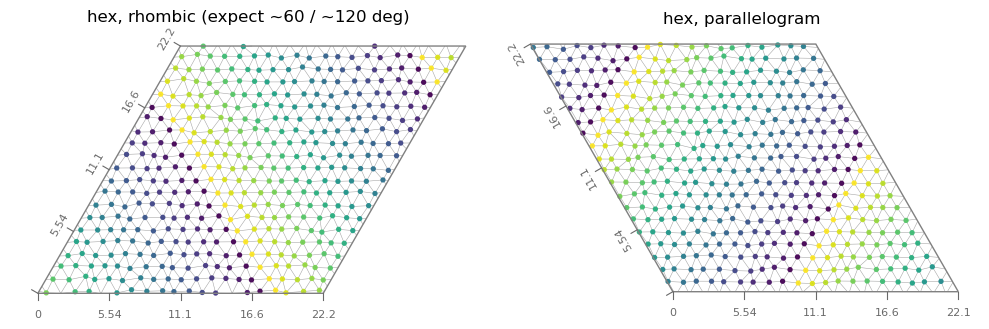

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
vis.plot_embedding_with_torus_edges(G=G_hex, torus=proj_r, ax=axes[0], colors=colors_hex, edge_alpha=0.35, s=8)
axes[0].set_title('hex, rhombic (expect ~60 / ~120 deg)')
vis.plot_embedding_with_torus_edges(G=G_hex, torus=proj_p, ax=axes[1], colors=colors_hex, edge_alpha=0.35, s=8)
axes[1].set_title('hex, parallelogram')
plt.tight_layout()

# --> rhombic learns correct angle (60 or 120), parallelogram learns correct angle an equal side lengths

In [26]:
# parallelogram mode on a 20x40 grid: expect ~rectangular (x ~ 0, aspect ~ 2)
G40, D40 = graphio.get_periodic_lattice(20, 40)
colors40 = [i for (i, j) in G40.nodes()]

In [27]:
proj = MDSTorusProjector()
X = proj.fit_transform(D40, learn_mode='parallelogram', y_init=2)
print('parallelogram on 20x40:',
      'alpha=%.4g' % proj.alpha_, 'x=%.4g' % proj.x_, 'y=%.4g' % proj.y_,
      'r1/r0=%.3f' % (proj.r1_ / proj.r0_), 'theta=%.1f' % np.degrees(proj.theta_),
      'stress=%.4g' % torus_stress(X, D40, proj))

parallelogram on 20x40: alpha=38.95 x=0.005689 y=1.008 r1/r0=1.008 theta=89.7 stress=0.216


Text(0.5, 1.0, '20x40 grid, parallelogram mode (expect x~0, aspect~2)')

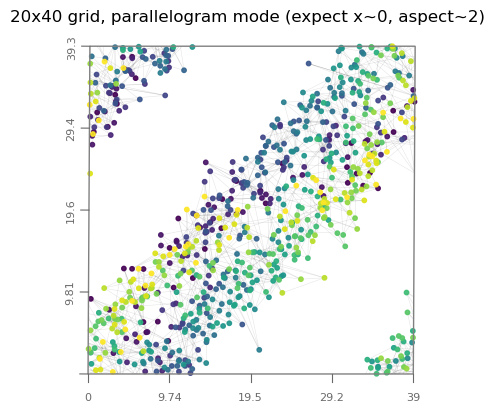

In [28]:
fig, ax = plt.subplots()
vis.plot_embedding_with_torus_edges(G=G40, torus=proj, ax=ax, colors=colors40)
ax.set_title('20x40 grid, parallelogram mode (expect x~0, aspect~2)')

In [29]:
# rhombic: learn the angle (start off the square saddle at theta=90)
proj_r40 = MDSTorusProjector()
Xr40 = proj_r40.fit_transform(D40, learn_mode='rhombic', theta=100.0)
print('rhombic on hex:', 'alpha=%.4g' % proj_r40.alpha_,
      'theta=%.1f' % np.degrees(proj_r40.theta_),
      'r1/r0=%.3f' % (proj_r40.r1_ / proj_r40.r0_),
      'stress=%.4g' % torus_stress(Xr40, D40, proj_r40))

rhombic on hex: alpha=39.09 theta=89.8 r1/r0=1.000 stress=0.2154


In [30]:
# parallelogram: free shape
proj_p40 = MDSTorusProjector()
Xp40 = proj_p40.fit_transform(D40, learn_mode='parallelogram', r0_init=32, r1_init=46)
print('parallelogram on hex:', 'alpha=%.4g' % proj_p40.alpha_,
      'x=%.4g' % proj_p40.x_, 'y=%.4g' % proj_p40.y_,
      'theta=%.1f' % np.degrees(proj_p40.theta_),
      'stress=%.4g' % torus_stress(Xp40, D40, proj_p40))

parallelogram on hex: alpha=39.01 x=0.002043 y=1.003 theta=89.9 stress=0.216


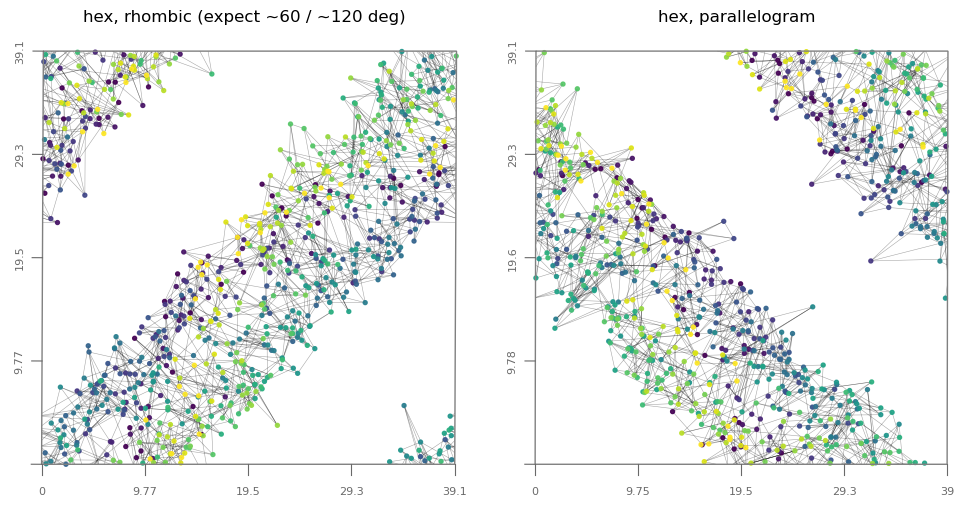

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
vis.plot_embedding_with_torus_edges(G=G40, torus=proj_r40, ax=axes[0], colors=colors40, edge_alpha=0.35, s=8)
axes[0].set_title('hex, rhombic (expect ~60 / ~120 deg)')
vis.plot_embedding_with_torus_edges(G=G40, torus=proj_p40, ax=axes[1], colors=colors40, edge_alpha=0.35, s=8)
axes[1].set_title('hex, parallelogram')
plt.tight_layout()

In [32]:
# anisotropic hexgrid --> does not work well...

In [33]:
# Grid cells on torus

In [34]:
a = np.load("grid_cells_4800.npz")
data = a['data']
spikes = a['spikes']

D_grid = pairwise_distances(data)

In [35]:
proj = MDSTorusProjector()
X = proj.fit_transform(D_grid)
stress = torus_stress(X, D_grid, proj)
print(f"stress={stress:.4g}")

stress=0.2498


Text(0.5, 0.98, 'Firing rates of selected cells on square torus\n Toroidal embedding, stress=0.2498')

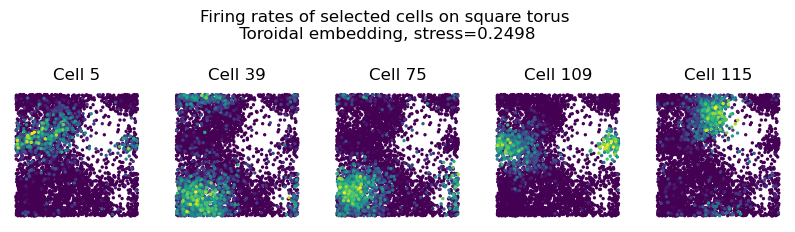

In [36]:
# spatial location of firing rates
fig, ax = plt.subplots(1, 5, figsize=(10, 3))

cell_ids = [5, 39, 75, 109, 115] # cells with clearly structured firing pattern

xx = X[:,0]
yy = X[:,1]
for i, idx in enumerate(cell_ids):
    order  = np.argsort(spikes[:, idx])  # to plot interesting time points on top
    ax[i].scatter(xx[order], yy[order], c=spikes[order, idx], s=2)
    ax[i].set_title(f"Cell {idx}")
    ax[i].axis("off")
    ax[i].set_aspect("equal")
fig.suptitle(f"Firing rates of selected cells on square torus\n Toroidal embedding, stress={stress:.4g}")

In [37]:
proj_fix_rhombus = MDSTorusProjector()
X_fix_rhombus = proj_fix_rhombus.fit_transform(D_grid, learn_mode='alpha', theta=60.0)

In [38]:
fix_rhombus_stress = torus_stress(X_fix_rhombus, D_grid, proj_fix_rhombus)
print(f"stress={fix_rhombus_stress:.4g}")

stress=0.2133


Text(0.5, 0.98, 'Firing rates of selected cells by spatial position\n Fixed rhombic embedding (theta=60.0) Stress=0.2133')

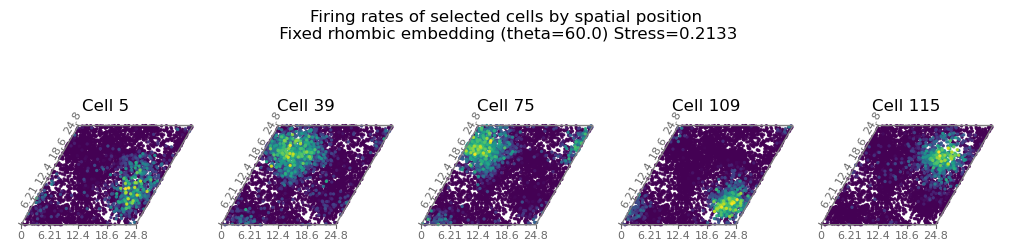

In [39]:
fig, ax = plt.subplots(1, 5, figsize=(10, 3), constrained_layout=True)

for i, idx in enumerate(cell_ids):
    order  = np.argsort(spikes[:, idx])  # to plot interesting time points on top
    vis.plot_embedding_with_torus_edges(torus=proj_fix_rhombus, ax=ax[i], order=order, colors=spikes[:, idx], edge_alpha=0.35, s=2)
    ax[i].set_title(f"Cell {idx}")
fig.suptitle(f"Firing rates of selected cells by spatial position\n Fixed rhombic embedding (theta=60.0) Stress={fix_rhombus_stress:.4g}")

In [40]:
# learn rhombus angle
proj_rhombus = MDSTorusProjector()
X_rhombus = proj_rhombus.fit_transform(D_grid, learn_mode='rhombic', theta=80.0)
rhombic_stress = torus_stress(X_rhombus, D_grid, proj_rhombus)
print(f"stress={rhombic_stress:.4g}")
print(f"theta = {np.degrees(proj_rhombus.theta_)}")

stress=0.2128
theta = 118.22999598783264


In [41]:
dir(proj_rhombus)

['__annotations__',
 '__class__',
 '__dataclass_fields__',
 '__dataclass_params__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__lt__',
 '__match_args__',
 '__module__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__sizeof__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 '_embed',
 '_project_to_torus',
 'alpha_',
 'embedding_',
 'fit',
 'fit_transform',
 'learning_rate',
 'n_components',
 'projection',
 'r0_',
 'r1_',
 'random_state',
 'stochastic_gradient_descent',
 'theta_',
 'torus_embedding_',
 'transform',
 'x_',
 'y_']

Text(0.5, 0.98, 'Firing rates of selected cells\n Learned rhombic embedding Stress=0.2128, Theta=118.2')

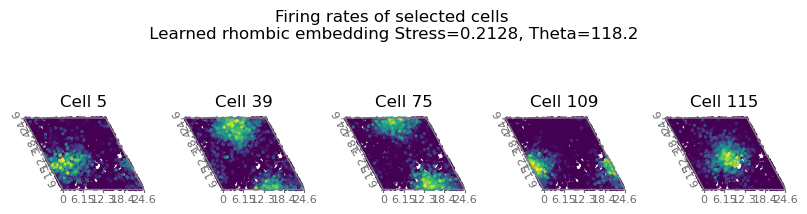

In [42]:
fig, ax = plt.subplots(1, 5, figsize=(10, 3))

for i, idx in enumerate(cell_ids):
    order  = np.argsort(spikes[:, idx])  # to plot interesting time points on top
    vis.plot_embedding_with_torus_edges(torus=proj_rhombus, ax=ax[i], order=order, colors=spikes[:, idx], edge_alpha=0.35, s=2)
    ax[i].set_title(f"Cell {idx}")
fig.suptitle(f"Firing rates of selected cells\n Learned rhombic embedding Stress={rhombic_stress:.4g}, Theta={np.degrees(proj_rhombus.theta_):.4g}")

In [43]:
# learn full parallelogram
proj_para = MDSTorusProjector()
X_para = proj_para.fit_transform(D_grid, learn_mode='parallelogram', theta=80.0)

In [44]:
para_stress = torus_stress(X_para, D_grid, proj_para)
print(f"stress={para_stress:.4g}")
print(f"theta = {np.degrees(proj_para.theta_)}")

stress=0.2128
theta = 61.81729923133495


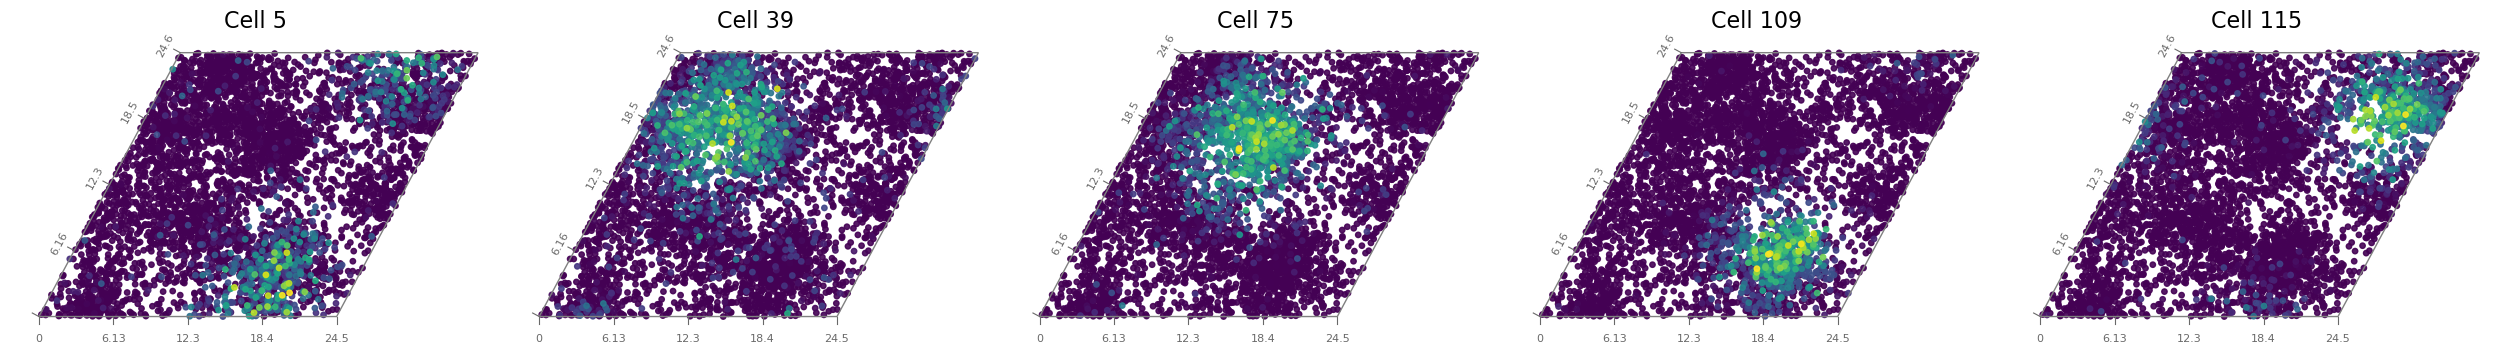

In [67]:
fig, ax = plt.subplots(1, 5, figsize=(25, 5), constrained_layout=True)
for i, idx in enumerate(cell_ids):
    order  = np.argsort(spikes[:, idx])  # to plot interesting time points on top
    vis.plot_embedding_with_torus_edges(torus=proj_para, ax=ax[i], order=order, colors=spikes[:, idx], edge_alpha=0.35, s=15)
    ax[i].set_title(f"Cell {idx}", fontsize=16)
# fig.suptitle(f"Firing rates of selected cells by spatial position\n Learned parallelogram embedding Stress={para_stress:.4g}, theta={np.degrees(proj_para.theta_):.4g}")
fig.savefig("poster/grid_cells-rhombus.pdf",dpi=200)